# CSS Track-3 Style Hypothesis Testing (DSS vs WER)

This notebook:
- uses the fixed filter `CROSS_MODEL_CLIP_REGEX`,
- compares DSS-WER (stored as `mrs_wer`) vs WER on paired clips,
- runs paired randomization (permutation sign-flip) tests with fixed seed `1234`,
- reports overlap/non-overlap summaries, and
- plots mean difference $(DSS\text{-}WER - WER)$ against overlap ratio.

In [8]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 1234
N_PERM = 10000
N_BOOT = 5000

CROSS_MODEL_CLIP_REGEX = r"(^mix_[0-9]+_0\.(00|14|20|40)_2_7\.4_T$)|(^mix_[0-9]+_0\.14_2_(None|7\.4|0|-5)_T$)"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "WER_Results_by_Model").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "WER_Results_by_Model"
MANIFEST_PATH = PROJECT_ROOT / "Output" / "manifest.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:   {RESULTS_DIR}")
print(f"Manifest:      {MANIFEST_PATH}")
print(f"Seed:          {SEED}")

Project root: /home/jamin/Year3Proj
Results dir:   /home/jamin/Year3Proj/WER_Results_by_Model
Manifest:      /home/jamin/Year3Proj/Output/manifest.csv
Seed:          1234


In [9]:
def _parse_overlap_from_clip_id(clip_id: str):
    try:
        # Example: mix_0000047_0.14_2_-5_T
        return float(str(clip_id).split("_")[2])
    except Exception:
        return np.nan


def load_model_results(results_dir: Path) -> pd.DataFrame:
    rows = []
    for result_path in sorted(results_dir.glob("*_wer_results.json")):
        with open(result_path, "r", encoding="utf-8") as f:
            payload = json.load(f)
        model_name = payload.get("model", result_path.stem.replace("_wer_results", ""))

        for item in payload.get("results", []):
            if item.get("status") != "success":
                continue
            metrics = item.get("metrics", {})
            rows.append(
                {
                    "model": model_name,
                    "clip_id": item.get("clip_id"),
                    "wer": pd.to_numeric(metrics.get("wer"), errors="coerce"),
                    "dss_wer": pd.to_numeric(metrics.get("mrs_wer"), errors="coerce"),
                }
            )

    return pd.DataFrame(rows)


results_df = load_model_results(RESULTS_DIR)
results_df = results_df[results_df["clip_id"].astype(str).str.match(CROSS_MODEL_CLIP_REGEX, na=False)].copy()
results_df = results_df.dropna(subset=["wer", "dss_wer"]).copy()

manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_overlap = manifest_df[["clip_id", "overlap_ratio_target"]].copy() if "overlap_ratio_target" in manifest_df.columns else pd.DataFrame(columns=["clip_id", "overlap_ratio_target"])

analysis_df = results_df.merge(manifest_overlap, on="clip_id", how="left")
analysis_df["overlap_ratio"] = analysis_df["overlap_ratio_target"]
analysis_df["overlap_ratio"] = analysis_df["overlap_ratio"].fillna(analysis_df["clip_id"].map(_parse_overlap_from_clip_id))
analysis_df["overlap_ratio"] = pd.to_numeric(analysis_df["overlap_ratio"], errors="coerce")
analysis_df["overlap_group"] = np.where(np.isclose(analysis_df["overlap_ratio"].fillna(0.0), 0.0), "non-overlap", "overlap")
analysis_df["diff_dss_minus_wer"] = analysis_df["dss_wer"] - analysis_df["wer"]
analysis_df["abs_diff"] = analysis_df["diff_dss_minus_wer"].abs()

print(f"Rows after filter: {len(analysis_df)}")
print(f"Models: {sorted(analysis_df['model'].unique().tolist())}")
display(analysis_df.head())

Rows after filter: 2800
Models: ['faster-whisper', 'parakeet', 'wav2vec2', 'whisperx']


,model,clip_id,wer,dss_wer,overlap_ratio_target,overlap_ratio,overlap_group,diff_dss_minus_wer,abs_diff
0,faster-whisper,mix_0000005_0.00_2_7.4_T,0.027322,0.027322,0.0,0.0,non-overlap,0.000000,0.000000
1,faster-whisper,mix_0000017_0.00_2_7.4_T,0.049505,0.059406,0.0,0.0,non-overlap,0.009901,0.009901
2,faster-whisper,mix_0000029_0.00_2_7.4_T,0.007246,0.007246,0.0,0.0,non-overlap,0.000000,0.000000
3,faster-whisper,mix_0000041_0.00_2_7.4_T,0.010989,0.010989,0.0,0.0,non-overlap,0.000000,0.000000
4,faster-whisper,mix_0000053_0.00_2_7.4_T,0.027174,0.027174,0.0,0.0,non-overlap,0.000000,0.000000


In [10]:
def paired_sign_flip_test(diff: np.ndarray, n_perm: int = 10000, seed: int = 1234):
    """
    CSS track-3 style paired randomization via sign-flip permutations.
    H0: mean(diff) = 0 (no paired difference)
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(diff, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, 0

    observed = float(np.mean(x))
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_perm, n), replace=True)
    perm_means = np.mean(signs * x, axis=1)

    # Two-sided p-value
    p_two_sided = float((np.sum(np.abs(perm_means) >= abs(observed)) + 1) / (n_perm + 1))
    p_left = float((np.sum(perm_means <= observed) + 1) / (n_perm + 1))
    p_right = float((np.sum(perm_means >= observed) + 1) / (n_perm + 1))
    return observed, p_two_sided, p_left, p_right, n


def bootstrap_ci_mean(diff: np.ndarray, n_boot: int = 5000, seed: int = 1234, alpha: float = 0.05):
    rng = np.random.default_rng(seed)
    x = np.asarray(diff, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan

    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = np.mean(x[idx], axis=1)
    lo = float(np.quantile(boot_means, alpha / 2))
    hi = float(np.quantile(boot_means, 1 - alpha / 2))
    return lo, hi

In [11]:
# Hypothesis tests by model and overlap group, plus an overall row.
test_rows = []
for (model_name, overlap_group), g in analysis_df.groupby(["model", "overlap_group"], sort=True):
    obs, p2, p_left, p_right, n = paired_sign_flip_test(g["diff_dss_minus_wer"].to_numpy(), n_perm=N_PERM, seed=SEED)
    ci_lo, ci_hi = bootstrap_ci_mean(g["diff_dss_minus_wer"].to_numpy(), n_boot=N_BOOT, seed=SEED)
    test_rows.append(
        {
            "model": model_name,
            "overlap_group": overlap_group,
            "n": n,
            "mean_dss_minus_wer": obs,
            "ci95_low": ci_lo,
            "ci95_high": ci_hi,
            "p_two_sided": p2,
            "p_left": p_left,
            "p_right": p_right,
        }
    )

obs, p2, p_left, p_right, n = paired_sign_flip_test(analysis_df["diff_dss_minus_wer"].to_numpy(), n_perm=N_PERM, seed=SEED)
ci_lo, ci_hi = bootstrap_ci_mean(analysis_df["diff_dss_minus_wer"].to_numpy(), n_boot=N_BOOT, seed=SEED)
test_rows.append(
    {
        "model": "ALL",
        "overlap_group": "ALL",
        "n": n,
        "mean_dss_minus_wer": obs,
        "ci95_low": ci_lo,
        "ci95_high": ci_hi,
        "p_two_sided": p2,
        "p_left": p_left,
        "p_right": p_right,
    }
)

hypothesis_df = pd.DataFrame(test_rows).sort_values(["model", "overlap_group"]).reset_index(drop=True)
print("Paired sign-flip randomization test on (DSS-WER - WER), seed=1234")
display(hypothesis_df.round(6))

Paired sign-flip randomization test on (DSS-WER - WER), seed=1234


,model,overlap_group,n,mean_dss_minus_wer,ci95_low,ci95_high,p_two_sided,p_left,p_right
0,ALL,ALL,2800,-0.002783,-0.003992,-0.001590,0.000100,0.0001,1.000000
1,faster-whisper,non-overlap,100,0.008850,0.003548,0.015503,0.000200,0.9999,0.000200
2,faster-whisper,overlap,600,-0.004883,-0.007497,-0.002316,0.000300,0.0002,0.999900
3,parakeet,non-overlap,100,0.009390,0.004578,0.015586,0.000100,1.0000,0.000100
4,parakeet,overlap,600,0.011578,0.008564,0.014722,0.000100,1.0000,0.000100
5,wav2vec2,non-overlap,100,0.001538,0.000696,0.002598,0.000300,1.0000,0.000300
6,wav2vec2,overlap,600,-0.020067,-0.022356,-0.017898,0.000100,0.0001,1.000000
7,whisperx,non-overlap,100,0.000735,0.000156,0.001603,0.018898,1.0000,0.009399
8,whisperx,overlap,600,-0.003035,-0.005217,-0.000971,0.003200,0.0015,0.998600


## 4.9.3 Monte Carlo Permutation Test

This section adds a Monte Carlo permutation test for paired DSS-WER vs WER comparisons.

For each paired clip score $(x_i, y_i)$ where $x_i=\text{DSS-WER}_i$ and $y_i=\text{WER}_i$, we test:

- $H_0$: no systematic difference between DSS-WER and WER
- $H_1$: DSS-WER and WER differ in mean

The Monte Carlo null distribution is generated by randomly swapping each pair $(x_i, y_i)$ with probability 0.5 per permutation, using fixed seed `1234`.

In [16]:
def monte_carlo_permutation_test_paired(
    x: np.ndarray,
    y: np.ndarray,
    n_perm: int = 10000,
    seed: int = 1234,
):
    """Paired Monte Carlo permutation test by random within-pair swaps."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x = x[keep]
    y = y[keep]

    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan, 0

    rng = np.random.default_rng(seed)
    observed = float(np.mean(x - y))

    # swap_mask[p, i] == True means swap x_i and y_i in permutation p.
    swap_mask = rng.random((n_perm, n)) < 0.5
    x_perm = np.where(swap_mask, y, x)
    y_perm = np.where(swap_mask, x, y)
    perm_diffs = np.mean(x_perm - y_perm, axis=1)

    p_two_sided = float((np.sum(np.abs(perm_diffs) >= abs(observed)) + 1) / (n_perm + 1))
    p_left = float((np.sum(perm_diffs <= observed) + 1) / (n_perm + 1))
    p_right = float((np.sum(perm_diffs >= observed) + 1) / (n_perm + 1))

    return observed, p_two_sided, p_left, p_right, n


mc_rows = []
for (model_name, overlap_group), g in analysis_df.groupby(["model", "overlap_group"], sort=True):
    obs, p2, p_left, p_right, n = monte_carlo_permutation_test_paired(
        g["dss_wer"].to_numpy(),
        g["wer"].to_numpy(),
        n_perm=N_PERM,
        seed=SEED,
    )
    mc_rows.append(
        {
            "model": model_name,
            "overlap_group": overlap_group,
            "n": n,
            "mean_dss_minus_wer": obs,
            "mc_p_two_sided": p2,
            "mc_p_left": p_left,
            "mc_p_right": p_right,
        }
    )

obs, p2, p_left, p_right, n = monte_carlo_permutation_test_paired(
    analysis_df["dss_wer"].to_numpy(),
    analysis_df["wer"].to_numpy(),
    n_perm=N_PERM,
    seed=SEED,
)
mc_rows.append(
    {
        "model": "ALL",
        "overlap_group": "ALL",
        "n": n,
        "mean_dss_minus_wer": obs,
        "mc_p_two_sided": p2,
        "mc_p_left": p_left,
        "mc_p_right": p_right,
    }
)

mc_perm_df = pd.DataFrame(mc_rows).sort_values(["model", "overlap_group"]).reset_index(drop=True)
print("Section 4.9.3: Monte Carlo paired permutation test (DSS-WER vs WER), seed=1234")
display(mc_perm_df.round(6))

Section 4.9.3: Monte Carlo paired permutation test (DSS-WER vs WER), seed=1234


,model,overlap_group,n,mean_dss_minus_wer,mc_p_two_sided,mc_p_left,mc_p_right
0,ALL,ALL,2800,-0.002783,0.000100,0.0001,1.000000
1,faster-whisper,non-overlap,100,0.008850,0.000300,0.9999,0.000200
2,faster-whisper,overlap,600,-0.004883,0.000100,0.0001,1.000000
3,parakeet,non-overlap,100,0.009390,0.000100,1.0000,0.000100
4,parakeet,overlap,600,0.011578,0.000100,1.0000,0.000100
5,wav2vec2,non-overlap,100,0.001538,0.000700,1.0000,0.000400
6,wav2vec2,overlap,600,-0.020067,0.000100,0.0001,1.000000
7,whisperx,non-overlap,100,0.000735,0.015798,1.0000,0.006699
8,whisperx,overlap,600,-0.003035,0.003300,0.0017,0.998400


In [20]:
# Interpretation of Monte Carlo permutation results.
alpha = 0.05
practical_eps = 1e-3

interpret_df = mc_perm_df.copy()
interpret_df["significant"] = interpret_df["mc_p_two_sided"] < alpha
interpret_df["direction"] = np.select(
    [
        interpret_df["mean_dss_minus_wer"] < -practical_eps,
        interpret_df["mean_dss_minus_wer"] > practical_eps,
    ],
    ["DSS-WER lower (better)", "DSS-WER higher (worse)"],
    default="Nearly equal",
)
interpret_df["decision"] = np.where(
    interpret_df["significant"],
    "Reject H0 (difference detected)",
    "Fail to reject H0 (no clear difference)",
)

interpret_cols = [
    "model",
    "overlap_group",
    "n",
    "mean_dss_minus_wer",
    "mc_p_two_sided",
    "mc_p_left",
    "mc_p_right",
    "direction",
    "decision",
]

print(f"Interpretation using alpha={alpha} and practical epsilon={practical_eps}.")
display(interpret_df[interpret_cols].round(6))

print("\nConcise interpretation:")
for _, row in interpret_df.iterrows():
    print(
        f"- {row['model']} | {row['overlap_group']}: "
        f"mean(DSS-WER - WER)={row['mean_dss_minus_wer']:.6f}, "
        f"p(two-sided)={row['mc_p_two_sided']:.6f} -> "
        f"{row['direction']}; {row['decision']}"
    )

Interpretation using alpha=0.05 and practical epsilon=0.001.


,model,overlap_group,n,mean_dss_minus_wer,mc_p_two_sided,mc_p_left,mc_p_right,direction,decision
0,ALL,ALL,2800,-0.002783,0.000100,0.0001,1.000000,DSS-WER lower (better),Reject H0 (difference detected)
1,faster-whisper,non-overlap,100,0.008850,0.000300,0.9999,0.000200,DSS-WER higher (worse),Reject H0 (difference detected)
2,faster-whisper,overlap,600,-0.004883,0.000100,0.0001,1.000000,DSS-WER lower (better),Reject H0 (difference detected)
3,parakeet,non-overlap,100,0.009390,0.000100,1.0000,0.000100,DSS-WER higher (worse),Reject H0 (difference detected)
4,parakeet,overlap,600,0.011578,0.000100,1.0000,0.000100,DSS-WER higher (worse),Reject H0 (difference detected)
5,wav2vec2,non-overlap,100,0.001538,0.000700,1.0000,0.000400,DSS-WER higher (worse),Reject H0 (difference detected)
6,wav2vec2,overlap,600,-0.020067,0.000100,0.0001,1.000000,DSS-WER lower (better),Reject H0 (difference detected)
7,whisperx,non-overlap,100,0.000735,0.015798,1.0000,0.006699,Nearly equal,Reject H0 (difference detected)
8,whisperx,overlap,600,-0.003035,0.003300,0.0017,0.998400,DSS-WER lower (better),Reject H0 (difference detected)



Concise interpretation:
- ALL | ALL: mean(DSS-WER - WER)=-0.002783, p(two-sided)=0.000100 -> DSS-WER lower (better); Reject H0 (difference detected)
- faster-whisper | non-overlap: mean(DSS-WER - WER)=0.008850, p(two-sided)=0.000300 -> DSS-WER higher (worse); Reject H0 (difference detected)
- faster-whisper | overlap: mean(DSS-WER - WER)=-0.004883, p(two-sided)=0.000100 -> DSS-WER lower (better); Reject H0 (difference detected)
- parakeet | non-overlap: mean(DSS-WER - WER)=0.009390, p(two-sided)=0.000100 -> DSS-WER higher (worse); Reject H0 (difference detected)
- parakeet | overlap: mean(DSS-WER - WER)=0.011578, p(two-sided)=0.000100 -> DSS-WER higher (worse); Reject H0 (difference detected)
- wav2vec2 | non-overlap: mean(DSS-WER - WER)=0.001538, p(two-sided)=0.000700 -> DSS-WER higher (worse); Reject H0 (difference detected)
- wav2vec2 | overlap: mean(DSS-WER - WER)=-0.020067, p(two-sided)=0.000100 -> DSS-WER lower (better); Reject H0 (difference detected)
- whisperx | non-overlap: 

In [17]:
# Summary of DSS-WER and WER separately for non-overlap and overlap.
summary_df = (
    analysis_df.groupby(["model", "overlap_group"], as_index=False)
    .agg(
        clips=("clip_id", "count"),
        dss_mean=("dss_wer", "mean"),
        dss_median=("dss_wer", "median"),
        wer_mean=("wer", "mean"),
        wer_median=("wer", "median"),
        mean_diff_dss_minus_wer=("diff_dss_minus_wer", "mean"),
        median_diff_dss_minus_wer=("diff_dss_minus_wer", "median"),
    )
    .sort_values(["model", "overlap_group"])
)

overall_overlap_summary_df = (
    analysis_df.groupby(["overlap_group"], as_index=False)
    .agg(
        clips=("clip_id", "count"),
        dss_mean=("dss_wer", "mean"),
        dss_median=("dss_wer", "median"),
        wer_mean=("wer", "mean"),
        wer_median=("wer", "median"),
        mean_diff_dss_minus_wer=("diff_dss_minus_wer", "mean"),
        median_diff_dss_minus_wer=("diff_dss_minus_wer", "median"),
    )
    .sort_values(["overlap_group"])
)

print("Per-model DSS-WER vs WER summary by overlap group:")
display(summary_df.round(6))

print("Overall DSS-WER vs WER summary by overlap group:")
display(overall_overlap_summary_df.round(6))

Per-model DSS-WER vs WER summary by overlap group:


,model,overlap_group,clips,dss_mean,dss_median,wer_mean,wer_median,mean_diff_dss_minus_wer,median_diff_dss_minus_wer
0,faster-whisper,non-overlap,100,0.060761,0.034167,0.051910,0.033333,0.008850,0.000000
1,faster-whisper,overlap,600,0.171606,0.135997,0.176489,0.138495,-0.004883,0.000000
2,parakeet,non-overlap,100,0.316164,0.251931,0.306774,0.251931,0.009390,0.000000
3,parakeet,overlap,600,0.547841,0.570156,0.536263,0.548395,0.011578,0.000000
4,wav2vec2,non-overlap,100,0.041272,0.031549,0.039733,0.030476,0.001538,0.000000
5,wav2vec2,overlap,600,0.239462,0.207975,0.259529,0.219115,-0.020067,-0.011332
6,whisperx,non-overlap,100,0.038961,0.029944,0.038226,0.029499,0.000735,0.000000
7,whisperx,overlap,600,0.202116,0.171395,0.205150,0.180425,-0.003035,0.000000


Overall DSS-WER vs WER summary by overlap group:


,overlap_group,clips,dss_mean,dss_median,wer_mean,wer_median,mean_diff_dss_minus_wer,median_diff_dss_minus_wer
0,non-overlap,400,0.114289,0.040000,0.109161,0.039025,0.005128,0.0
1,overlap,2400,0.290256,0.223001,0.294358,0.235117,-0.004102,0.0


In [18]:
# Count outcomes: DSS > WER, DSS = WER, WER > DSS
eps = 1e-12
count_df = analysis_df.copy()
count_df["comparison"] = np.select(
    [
        count_df["dss_wer"] > count_df["wer"] + eps,
        np.isclose(count_df["dss_wer"], count_df["wer"], atol=eps),
        count_df["wer"] > count_df["dss_wer"] + eps,
    ],
    ["DSS > WER", "DSS = WER", "WER > DSS"],
    default="Other",
)

comparison_table = (
    count_df.groupby(["model", "overlap_group", "comparison"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "count"})
    .pivot_table(index=["model", "overlap_group"], columns="comparison", values="count", fill_value=0)
    .reset_index()
)

overall_comparison_table = (
    count_df.groupby(["overlap_group", "comparison"], as_index=False)["clip_id"]
    .count()
    .rename(columns={"clip_id": "count"})
    .pivot_table(index=["overlap_group"], columns="comparison", values="count", fill_value=0)
    .reset_index()
)

print("Counts by model and overlap group:")
display(comparison_table)

print("Overall counts by overlap group:")
display(overall_comparison_table)

Counts by model and overlap group:


comparison,model,overlap_group,DSS = WER,DSS > WER,WER > DSS
0,faster-whisper,non-overlap,81.0,17.0,2.0
1,faster-whisper,overlap,279.0,106.0,215.0
2,parakeet,non-overlap,72.0,24.0,4.0
3,parakeet,overlap,246.0,188.0,166.0
4,wav2vec2,non-overlap,87.0,13.0,0.0
5,wav2vec2,overlap,81.0,43.0,476.0
6,whisperx,non-overlap,93.0,7.0,0.0
7,whisperx,overlap,365.0,83.0,152.0


Overall counts by overlap group:


comparison,overlap_group,DSS = WER,DSS > WER,WER > DSS
0,non-overlap,333.0,61.0,6.0
1,overlap,971.0,420.0,1009.0


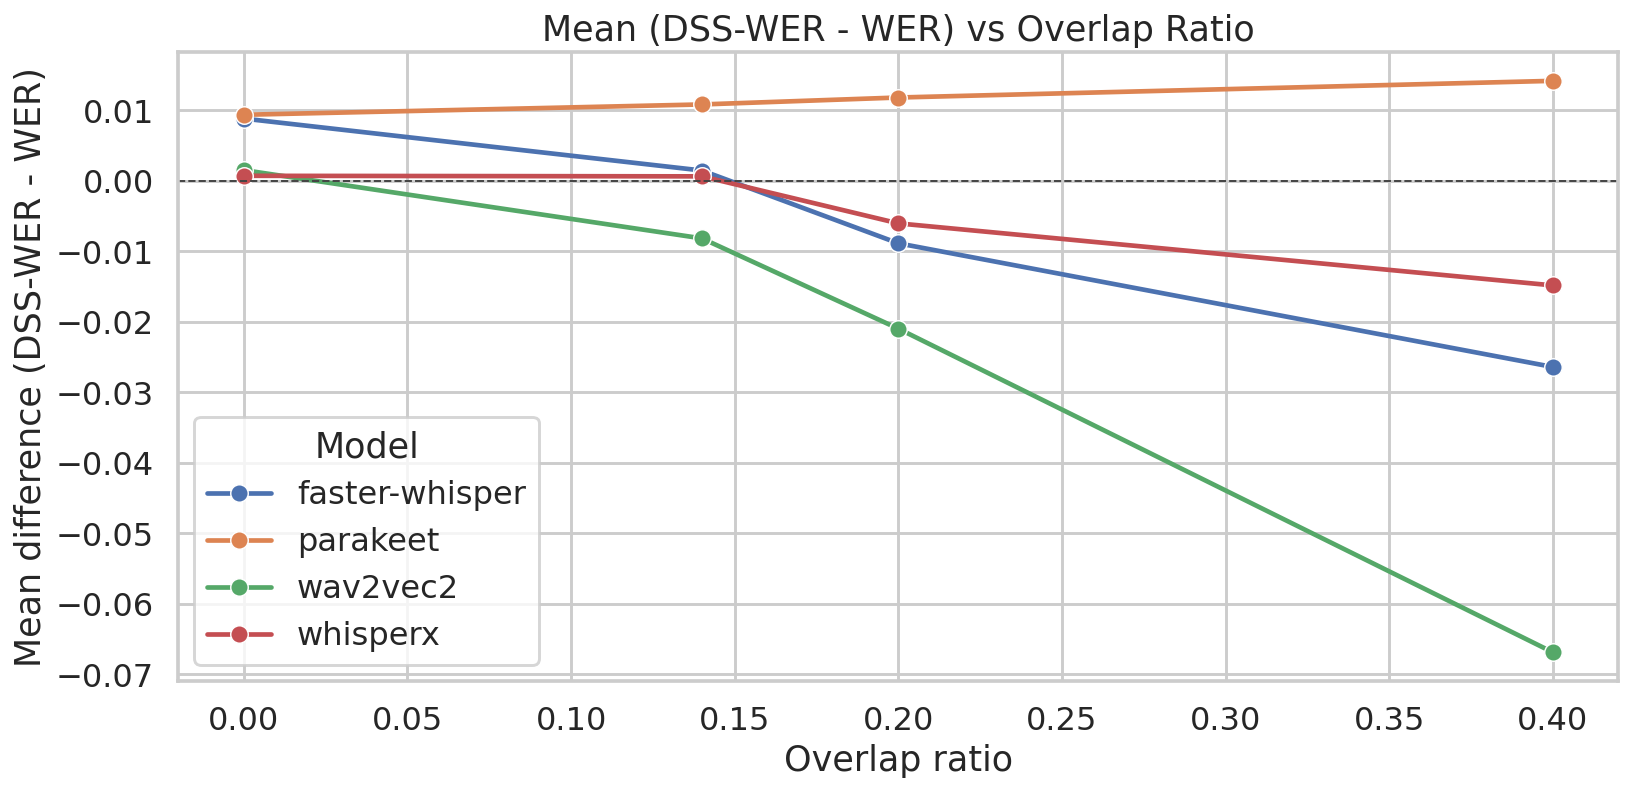

In [19]:
# Plot: mean (DSS-WER - WER) against overlap ratio
plot_df = (
    analysis_df.dropna(subset=["overlap_ratio", "diff_dss_minus_wer"])
    .groupby(["model", "overlap_ratio"], as_index=False)["diff_dss_minus_wer"]
    .mean()
    .sort_values(["model", "overlap_ratio"])
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="overlap_ratio",
    y="diff_dss_minus_wer",
    hue="model",
    marker="o",
    linewidth=2.4,
)
plt.axhline(0, color="#444444", linestyle="--", linewidth=1)
plt.title("Mean (DSS-WER - WER) vs Overlap Ratio")
plt.xlabel("Overlap ratio")
plt.ylabel("Mean difference (DSS-WER - WER)")
plt.legend(title="Model")
plt.tight_layout()
plt.show()